# Alignment sanity check: `data/processed/aligned_raw/`

**Purpose:** the aligned-dataset training run collapses to an all-background prediction (`val_dice` pinned at `0.0000`) even after switching to a combined BCE+Dice loss. Before tweaking hyperparameters further, this notebook visually and numerically checks whether `scripts/build_aligned_dataset.py`'s OpenCV template-matching output is actually valid -- or whether the masks it produced are blank/near-blank, which would make the collapse a data problem rather than a loss-function problem.

For 10 random patients, this shows side by side:
1. The full raw eye photo actually used for training (`data/processed/aligned_raw/images/{patient_id}.jpg`).
2. The *original* palpebral crop (`data/processed/masks/{patient_id}_palpebral.png`) -- a reference for what tissue region the mask is supposed to capture.
3. The new aligned mask, overlaid (semi-transparent red) on the same raw photo it's paired with for training -- with the mask's positive-pixel count printed directly in the title.

A bonus final section scans **all** masks in `aligned_raw/` (not just the 10 sampled) for blank or near-blank cases, since 10 random patients could miss a partial corruption.

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# Assumes the notebook is run from within notebooks/ (Jupyter's default cwd
# when opened from that folder). If running elsewhere (e.g. adapted for
# Kaggle), just set PROJECT_ROOT directly instead.
PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

ALIGNED_IMAGES_DIR = PROCESSED_DIR / "aligned_raw" / "images"
ALIGNED_MASKS_DIR = PROCESSED_DIR / "aligned_raw" / "masks"
ORIGINAL_CROPS_DIR = PROCESSED_DIR / "masks"  # Phase 0's original palpebral crop PNGs
SPLITS_CSV = PROCESSED_DIR / "dataset_splits.csv"

print("PROJECT_ROOT:        ", PROJECT_ROOT)
print("ALIGNED_IMAGES_DIR exists:", ALIGNED_IMAGES_DIR.exists())
print("ALIGNED_MASKS_DIR exists: ", ALIGNED_MASKS_DIR.exists())
print("ORIGINAL_CROPS_DIR exists:", ORIGINAL_CROPS_DIR.exists())
print("SPLITS_CSV exists:        ", SPLITS_CSV.exists())

PROJECT_ROOT:         D:\khaje\EYES-DEFY-ANEMIA
ALIGNED_IMAGES_DIR exists: True
ALIGNED_MASKS_DIR exists:  True
ORIGINAL_CROPS_DIR exists: True
SPLITS_CSV exists:         True


In [2]:
RANDOM_SEED = 42  # change (or remove the seed() call) for a different random sample each run
random.seed(RANDOM_SEED)

splits_df = pd.read_csv(SPLITS_CSV)
all_patient_ids = splits_df["patient_id"].tolist()

sample_patient_ids = random.sample(all_patient_ids, 10)
print("Sampled patients:", sample_patient_ids)

Sampled patients: ['Italy_069', 'India_029', 'India_007', 'Italy_096', 'India_071', 'India_063', 'India_058', 'India_036', 'Italy_095', 'India_027']


## Per-patient visual check (10 random patients)

Each row below is one patient: raw photo | original crop (reference) | aligned mask overlay. The overlay's title states the positive-pixel count explicitly -- if it says 0, the mask for that patient is completely blank.

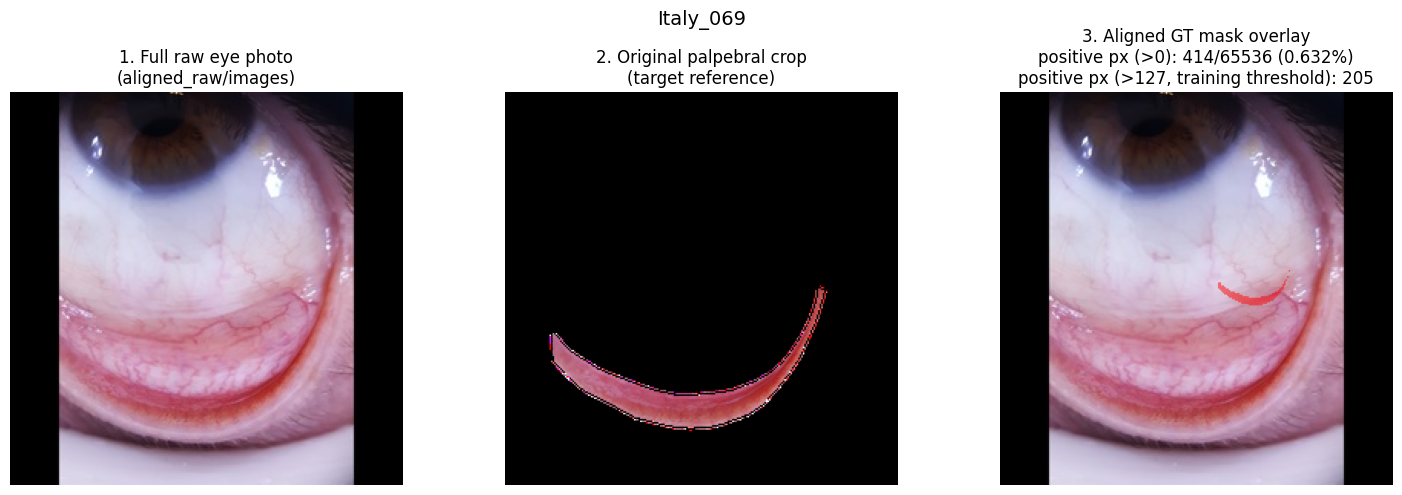

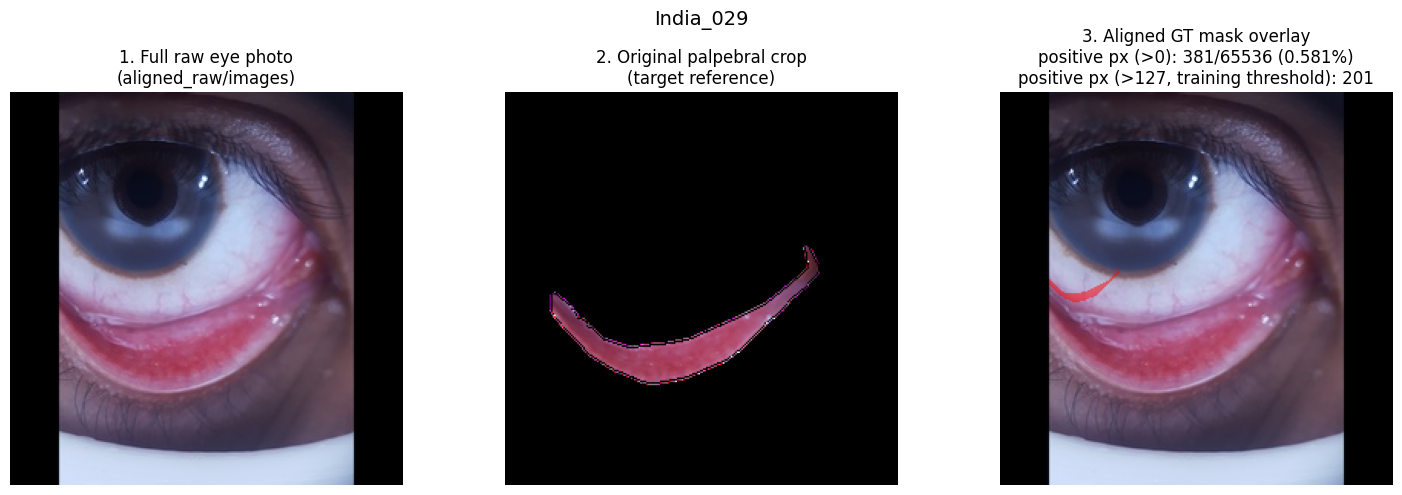

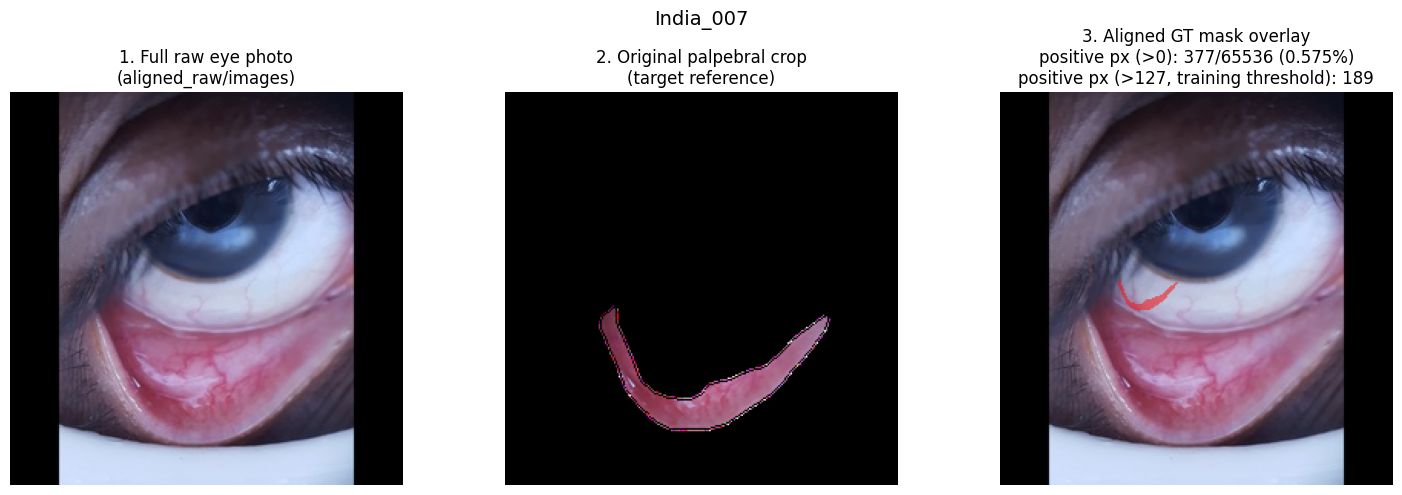

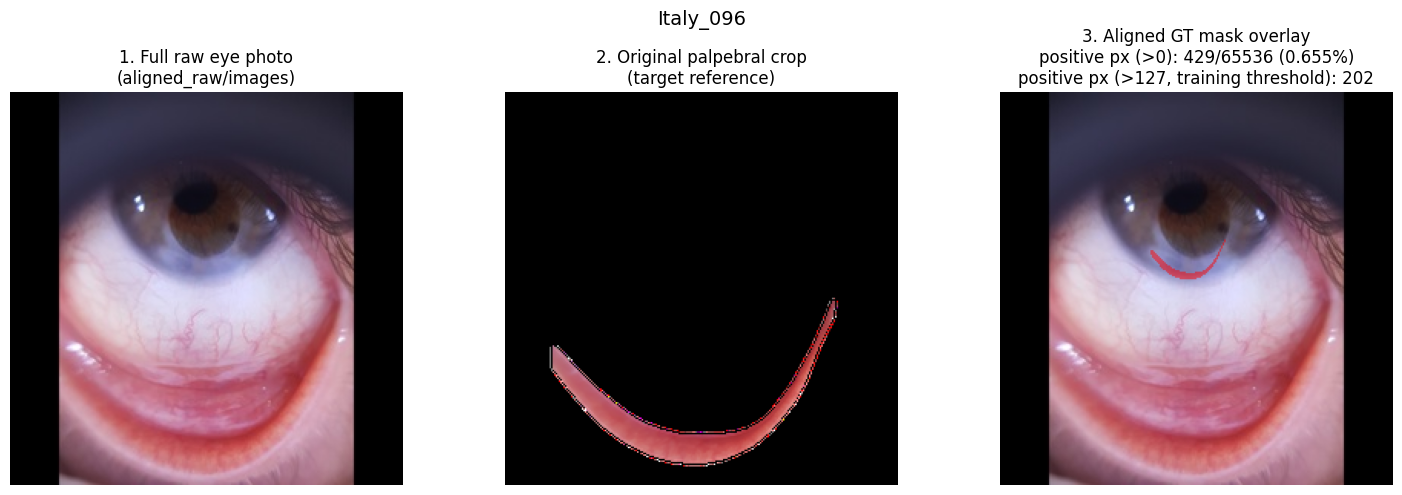

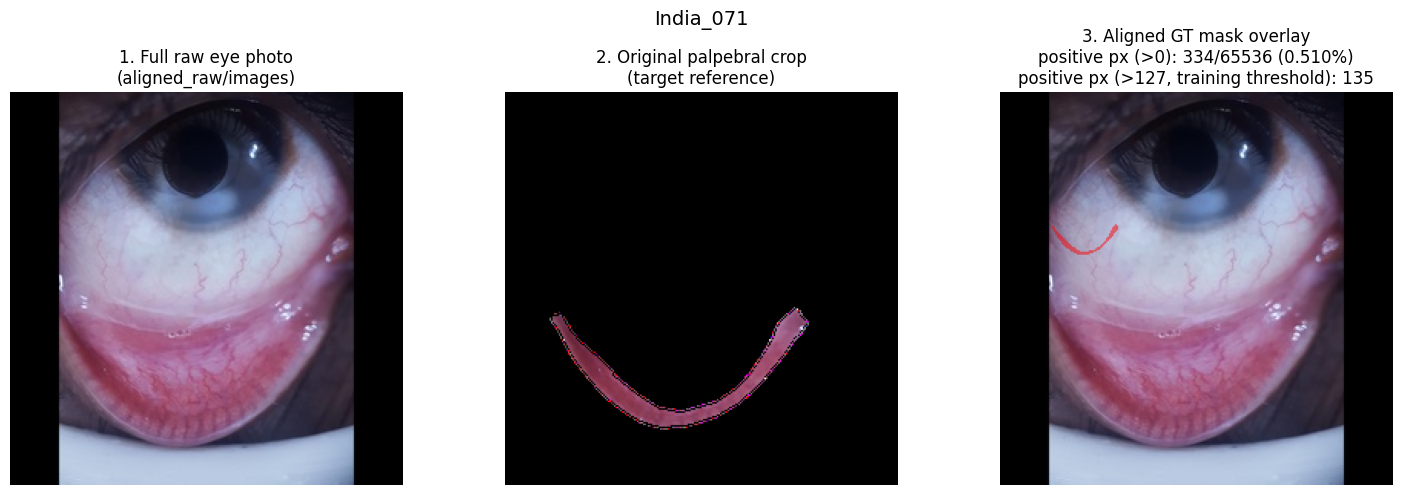

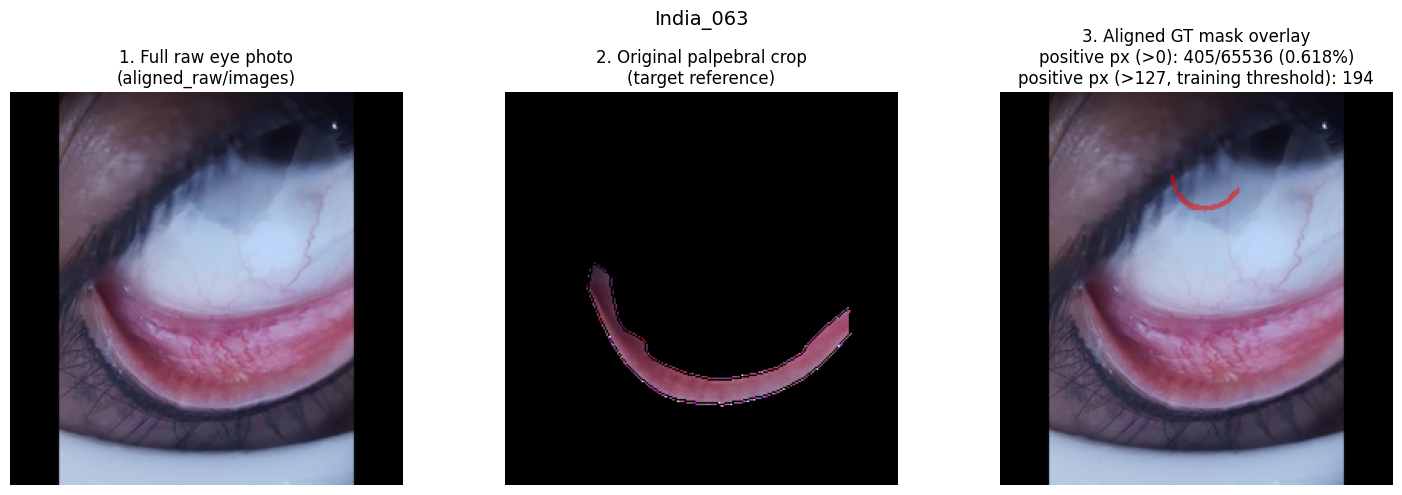

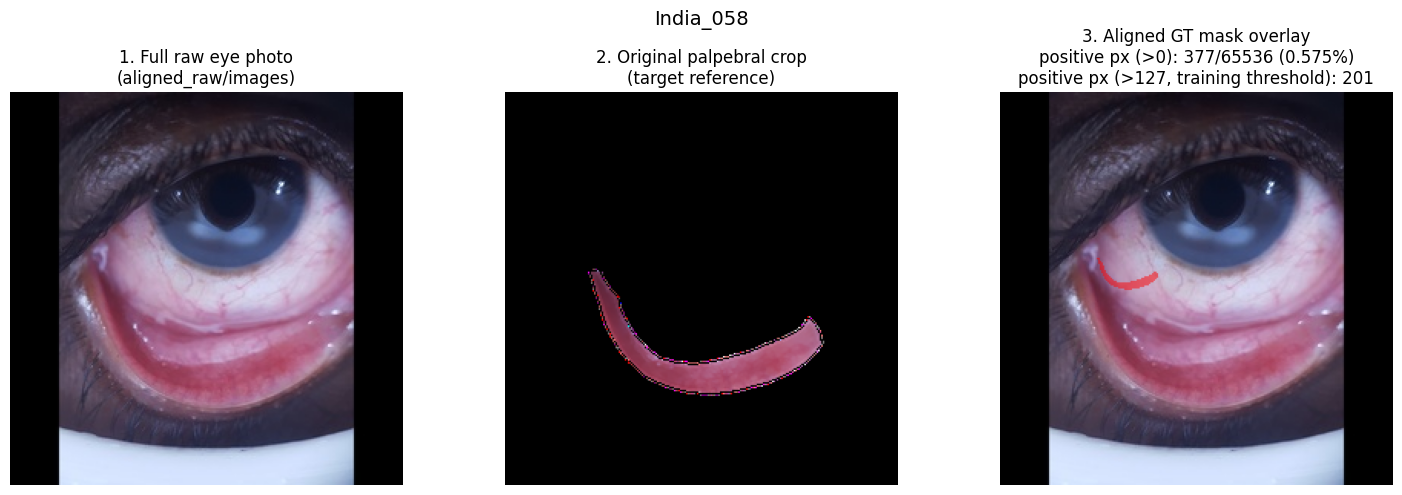

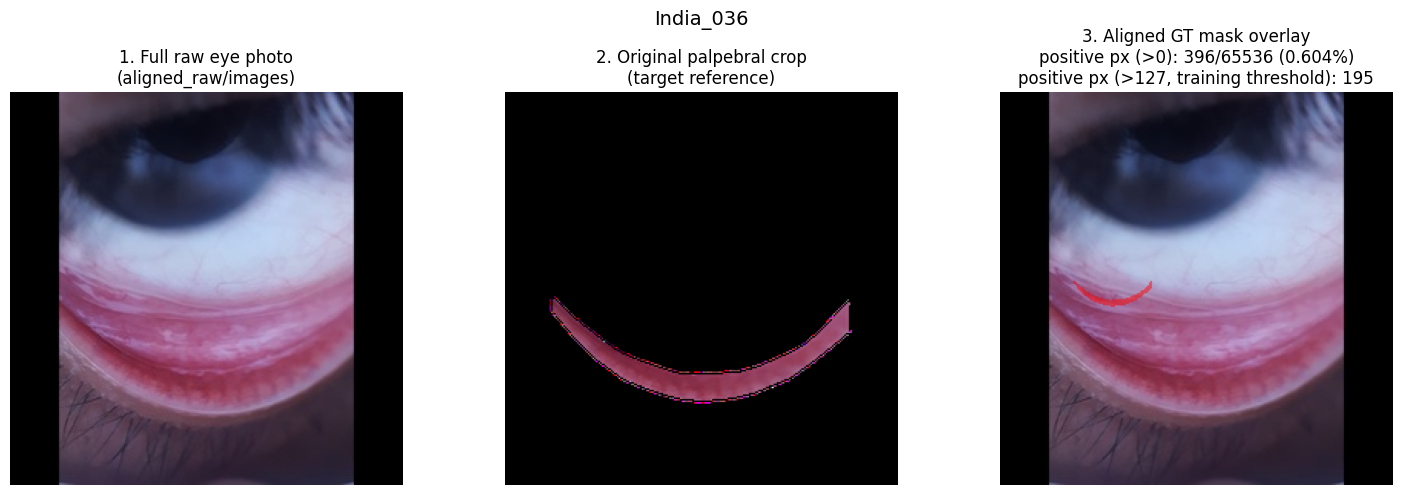

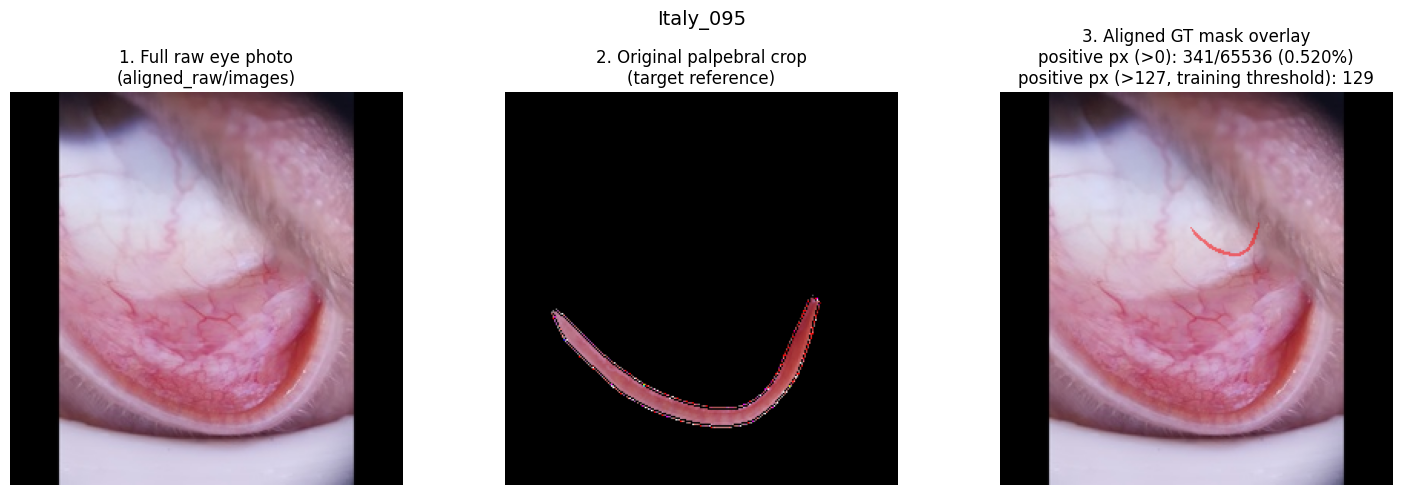

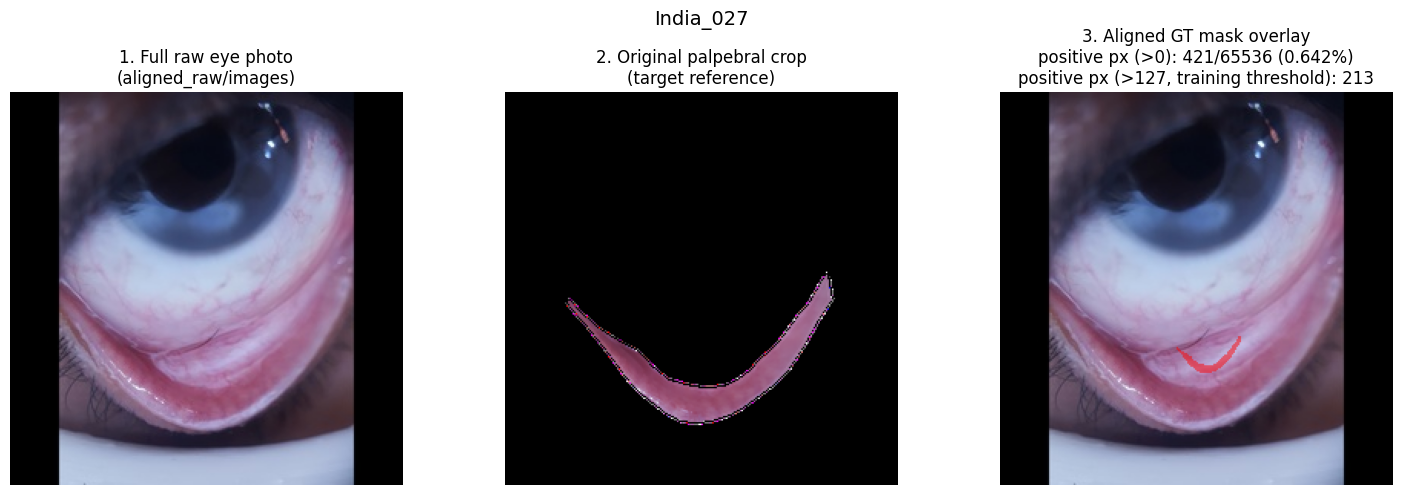

In [3]:
def load_aligned_pair(patient_id: str):
    image = np.array(Image.open(ALIGNED_IMAGES_DIR / f"{patient_id}.jpg").convert("RGB"))
    mask = np.array(Image.open(ALIGNED_MASKS_DIR / f"{patient_id}.png").convert("L"))
    return image, mask


def load_original_crop(patient_id: str):
    path = ORIGINAL_CROPS_DIR / f"{patient_id}_palpebral.png"
    return np.array(Image.open(path).convert("RGB"))


def make_overlay(image: np.ndarray, mask: np.ndarray, alpha: float = 0.5) -> np.ndarray:
    mask_bin = (mask > 127).astype(np.float32)
    red = np.zeros_like(image, dtype=np.float32)
    red[..., 0] = 255
    blended = image.astype(np.float32) * (1 - alpha * mask_bin[..., None]) + red * (alpha * mask_bin[..., None])
    return blended.astype(np.uint8)


for patient_id in sample_patient_ids:
    aligned_image, aligned_mask = load_aligned_pair(patient_id)
    original_crop = load_original_crop(patient_id)
    overlay = make_overlay(aligned_image, aligned_mask)

    # Crucial check: literal "any nonzero pixel at all" count, not the >127
    # binarization threshold -- this is the one that tells us if the mask
    # is 100% black, regardless of what threshold training actually uses.
    n_positive_strict = int((aligned_mask > 0).sum())
    n_positive_binarized = int((aligned_mask > 127).sum())  # threshold AlignedConjunctivaSegmentationDataset actually uses
    total_pixels = aligned_mask.size
    is_blank = n_positive_strict == 0

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f"{patient_id}" + ("   ***  MASK IS 100% BLACK  ***" if is_blank else ""),
        fontsize=14,
        color=("red" if is_blank else "black"),
    )

    axes[0].imshow(aligned_image)
    axes[0].set_title("1. Full raw eye photo\n(aligned_raw/images)")
    axes[0].axis("off")

    axes[1].imshow(original_crop)
    axes[1].set_title("2. Original palpebral crop\n(target reference)")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title(
        "3. Aligned GT mask overlay\n"
        f"positive px (>0): {n_positive_strict}/{total_pixels} ({100 * n_positive_strict / total_pixels:.3f}%)\n"
        f"positive px (>127, training threshold): {n_positive_binarized}"
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

## Bonus: full-dataset scan (all patients, not just the 10 sampled)

10 random patients could miss a partial corruption (e.g. only some patients broken). This scans every mask in `aligned_raw/masks/` and reports how many are fully blank or near-blank.

Scanning 217 mask files in D:\khaje\EYES-DEFY-ANEMIA\data\processed\aligned_raw\masks ...


count      217.000000
mean      1094.096774
std       3564.138756
min        186.000000
25%        330.000000
50%        385.000000
75%        482.000000
max      50176.000000
Name: positive_px, dtype: float64

Fully blank masks (0 positive pixels): 0 / 217

Near-blank masks (<10 positive pixels): 0 / 217


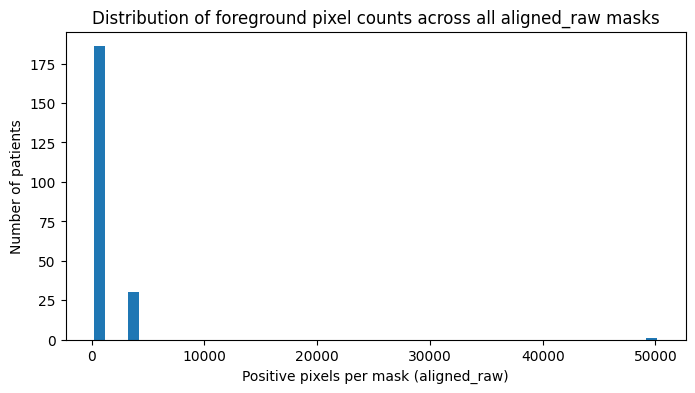

In [4]:
all_mask_paths = sorted(ALIGNED_MASKS_DIR.glob("*.png"))
print(f"Scanning {len(all_mask_paths)} mask files in {ALIGNED_MASKS_DIR} ...")

records = []
for mask_path in all_mask_paths:
    mask = np.array(Image.open(mask_path).convert("L"))
    n_positive = int((mask > 0).sum())
    records.append(
        {"patient_id": mask_path.stem, "positive_px": n_positive, "positive_frac": n_positive / mask.size}
    )

scan_df = pd.DataFrame(records)
print(scan_df["positive_px"].describe())

blank_masks = scan_df[scan_df["positive_px"] == 0]
print(f"\nFully blank masks (0 positive pixels): {len(blank_masks)} / {len(scan_df)}")
if len(blank_masks):
    print(blank_masks)

low_signal = scan_df[scan_df["positive_px"] < 10]
print(f"\nNear-blank masks (<10 positive pixels): {len(low_signal)} / {len(scan_df)}")
if len(low_signal):
    print(low_signal)

plt.figure(figsize=(8, 4))
plt.hist(scan_df["positive_px"], bins=50)
plt.xlabel("Positive pixels per mask (aligned_raw)")
plt.ylabel("Number of patients")
plt.title("Distribution of foreground pixel counts across all aligned_raw masks")
plt.show()